# Import Library: 분석에 사용할 모듈 설치
**1. Import Library**

In [1]:
!python -m pip install --user --upgrade pip

In [2]:
# Ignore the warnings
import warnings
# warnings.filterwarnings('always')
warnings.filterwarnings('ignore')

# System related and data input controls
import os

# Python path
import sys
module_location = [os.path.join(os.getcwd().split('DataScience')[0],'DataScience','Module')] 
for each in module_location:
    if each not in sys.path:
        sys.path.append(each)

# Auto reload of library
%reload_ext autoreload
%autoreload 2

from install_import_KK import *
from preprocessing_KK import *
from algorithm_deeplearning_KK import *
from evaluation_KK import *

# Deep Learning: Real Estate Prediction of California

## Parameters Setting

In [3]:
tf.random.set_seed(123)
Y_colname = ['Price']
SCALER = preprocessing.MinMaxScaler()
TEST_SIZE = 100
OUTPUT = 1
SEQUENCE = 20 # not MLP
DROPOUT_RATIO = 0.2
OPTIMIZER = 'adam'
BATCH_SIZE = 32
EPOCHS = 50 # 100
# Callback WalkForward
CALLBACK_TYPE = 'Optimal' # 'Process' or 'Optimal' or 'Dual'
EARLYSTOP_PATIENT = 10
#################
VERBOSE = 0
RESULT_LOCATION = os.path.join(os.getcwd(),'Result','RealEstateCalifornia_')
RESULT_DPI = 150
ALGO_NAMES = ['MLP', 'CNN', 'RNN', 'LSTM', 'GRU']

## MLP

Trasformed:
X_train: (300, 8) Y_train: (300, 1)
X_val: (100, 8) Y_val: (100, 1)
X_test: (100, 8) Y_test: (100, 1)
Model: "model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         [(None, 8)]               0         
_________________________________________________________________
dense (Dense)                (None, 128)               1152      
_________________________________________________________________
dropout (Dropout)            (None, 128)               0         
_________________________________________________________________
dense_1 (Dense)              (None, 64)                8256      
_________________________________________________________________
dropout_1 (Dropout)          (None, 64)                0         
_________________________________________________________________
dense_2 (Dense)              (None, 1)                 65        
Total params:

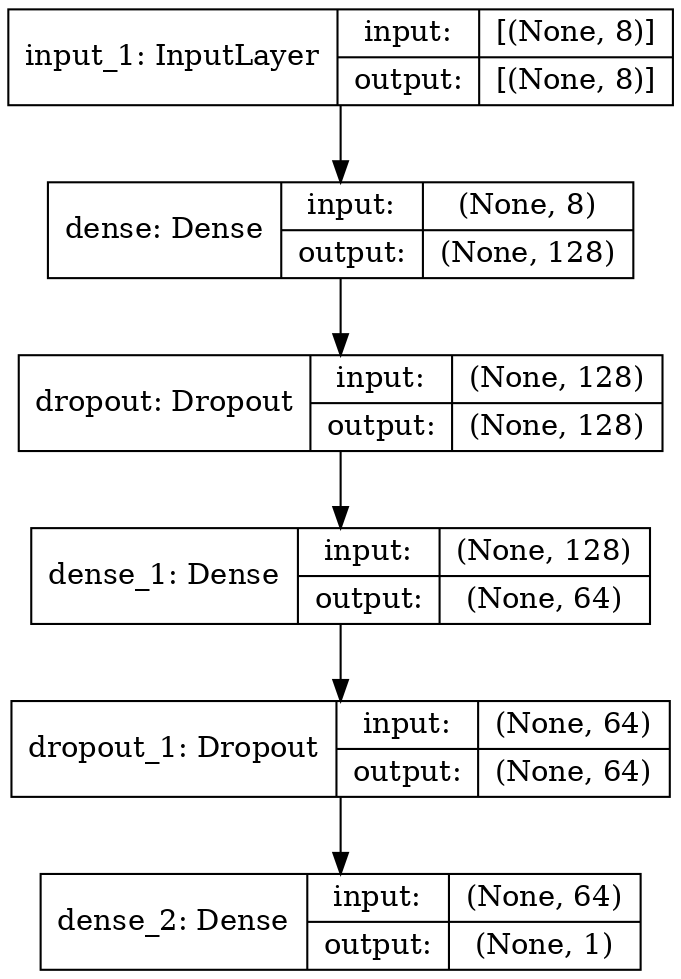

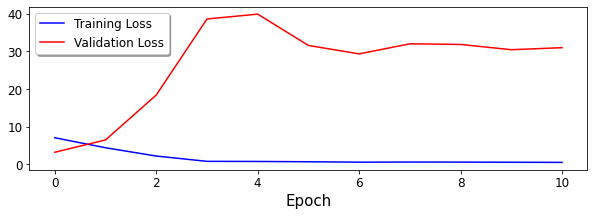

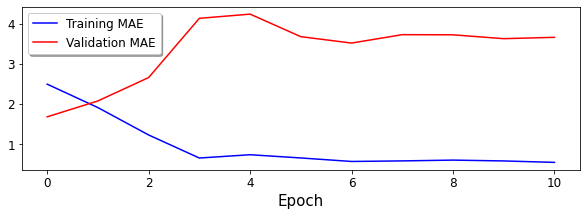

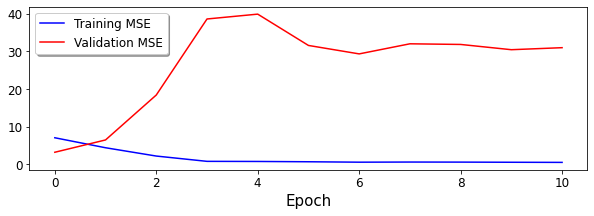

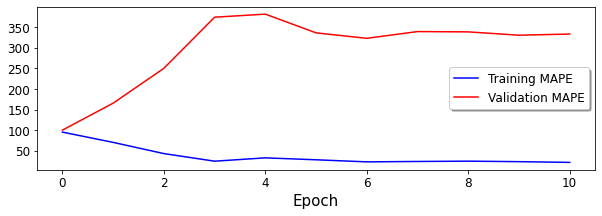

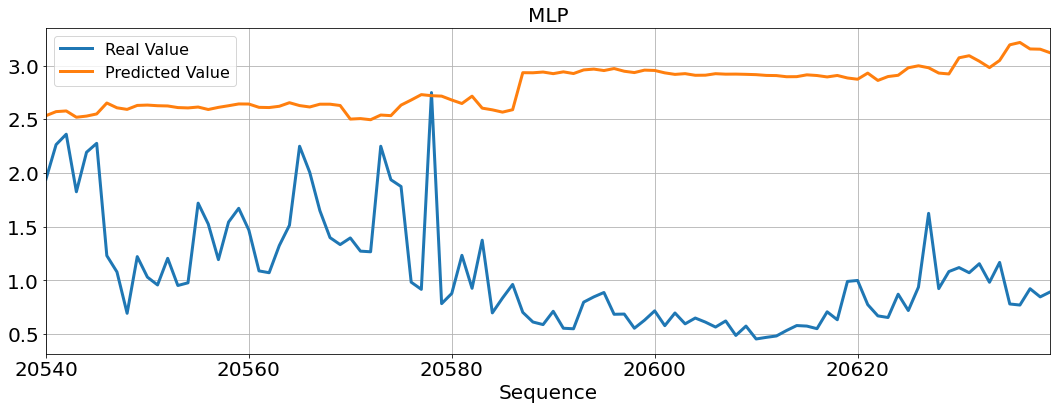

,MAE,MSE,MAPE
Score,1.73,3.39,2.21


In [4]:
# Data Loading
raw = fetch_california_housing()
df_X = pd.DataFrame(raw.data, columns=raw.feature_names)
df_Y = pd.DataFrame(raw.target, columns=['Price'])
df = pd.concat([df_Y, df_X], axis=1)
df = df[-500:].copy()

# Data Split and Scaling
X_train, Y_train, X_val, Y_val, X_test, Y_test = \
dl_preprocessing(df, Y_colname, TEST_SIZE=TEST_SIZE, SCALER=SCALER)

# MLP
algo_MLP = dl_MLP(X_train, OUTPUT, ACTIVATION='relu', DROPOUT_RATIO=DROPOUT_RATIO)
dl_show_structure(algo_MLP, RESULT_LOCATION=RESULT_LOCATION, 
                  RESULT_NAME='MLP.png', RESULT_DPI=150)

# Learning
algo_MLP, algo_MLPfit = dl_learning_reg(algo_MLP, X_train, Y_train, X_val, Y_val,
                                        OPTIMIZER=OPTIMIZER, 
                                        BATCH_SIZE=BATCH_SIZE, EPOCHS=EPOCHS,
                                        CALLBACK_TYPE=CALLBACK_TYPE, EARLYSTOP_PATIENT=EARLYSTOP_PATIENT,
                                        VERBOSE=VERBOSE, 
                                        RESULT_LOCATION=RESULT_LOCATION, RESULT_NAME='MLP.h5')
evaluation_reg_LearningPlot(algo_MLPfit)

# Prediction
Y_pred = algo_MLP.predict(X_test)
Y_pred = pd.DataFrame(Y_pred, index=Y_test.index, columns=Y_colname)

# Evaluation
evaluation_reg_PredPlot(Y_test, Y_pred, title='MLP', ylabel='')
Score, Resid_te = evaluation_reg_MAE_MSE_MAPE(Y_test, Y_pred)
display(Score)

# Summary
Score_MLP = Score.copy()
Y_pred_MLP = Y_pred.copy()

### Walk Forward

 99%|█████████▉| 99/100 [02:28<00:01,  1.71s/it]

Model: "model_100"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_101 (InputLayer)       [(None, 8)]               0         
_________________________________________________________________
dense_300 (Dense)            (None, 128)               1152      
_________________________________________________________________
dropout_200 (Dropout)        (None, 128)               0         
_________________________________________________________________
dense_301 (Dense)            (None, 64)                8256      
_________________________________________________________________
dropout_201 (Dropout)        (None, 64)                0         
_________________________________________________________________
dense_302 (Dense)            (None, 1)                 65        
Total params: 9,473
Trainable params: 9,473
Non-trainable params: 0
_______________________________________________________

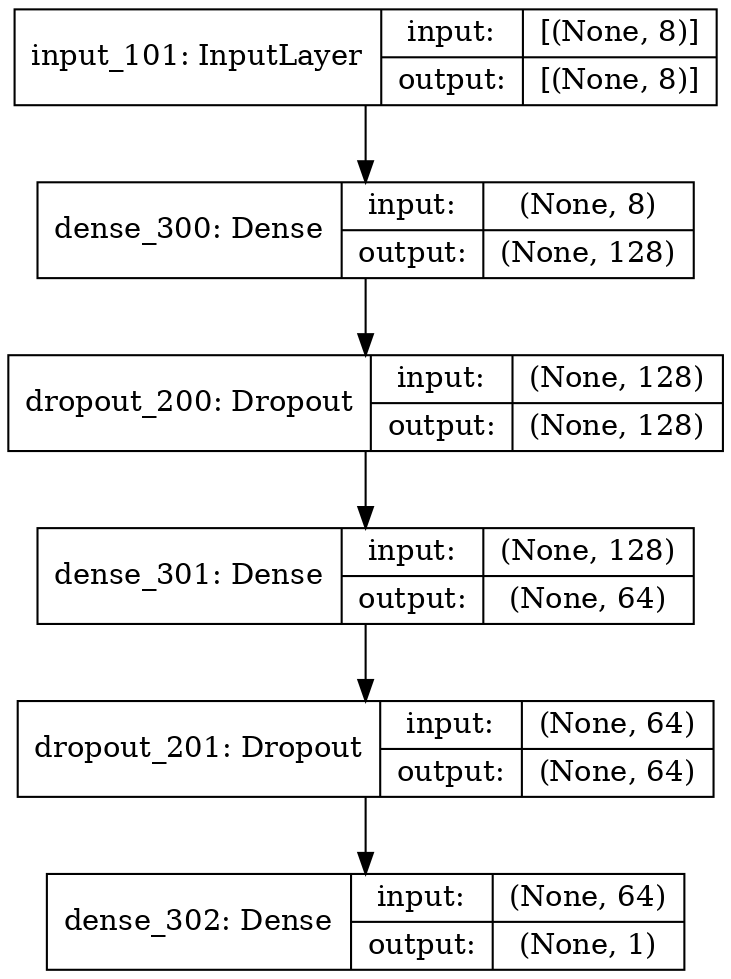

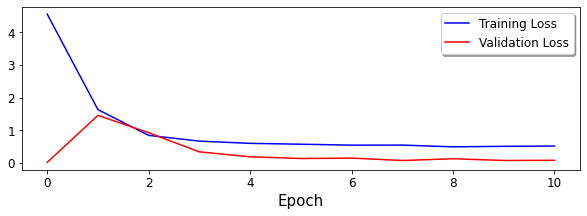

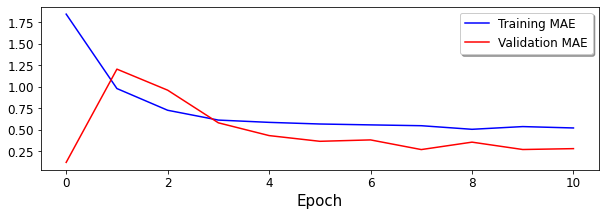

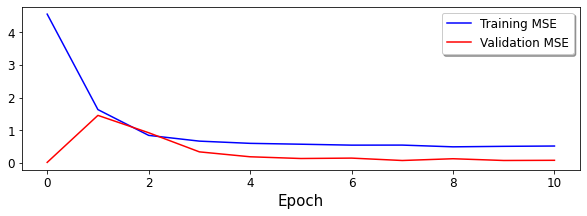

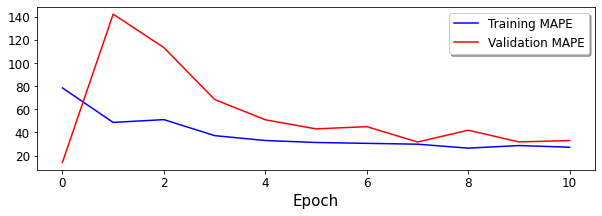

100%|██████████| 100/100 [02:30<00:00,  1.50s/it]


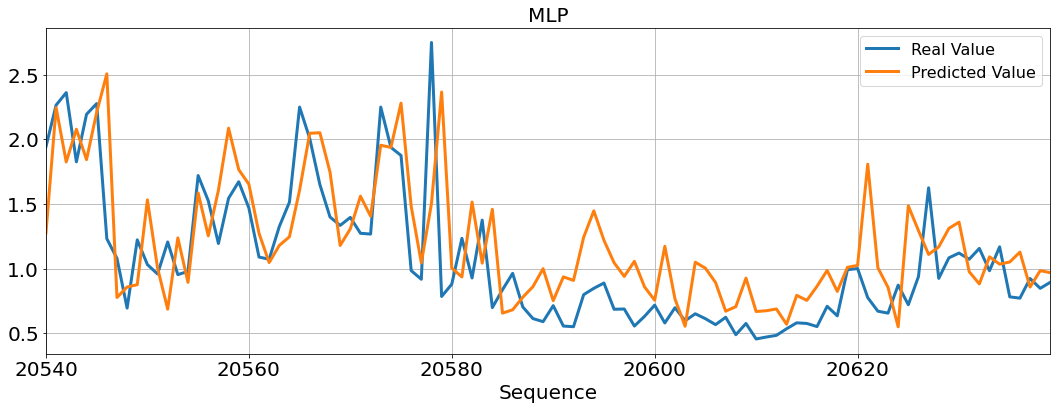

,MAE,MSE,MAPE
Score,0.31,0.17,0.34


In [5]:
# Data Loading
raw = fetch_california_housing()
df_X = pd.DataFrame(raw.data, columns=raw.feature_names)
df_Y = pd.DataFrame(raw.target, columns=['Price'])
df = pd.concat([df_Y, df_X], axis=1)
df = df[-500:].copy()

# Modeling
Y_real, Y_pred = pd.DataFrame(), pd.DataFrame()
spliter = TimeSeriesSplit(gap=0, n_splits=TEST_SIZE, test_size=OUTPUT)
for idx, (train_index, test_index) in tqdm(enumerate(spliter.split(df)), total=TEST_SIZE):
    # Data Split and Scaling
    X_train, Y_train, X_val, Y_val, X_test, Y_test = \
    dl_preprocessing_walkforward(df, Y_colname, train_index, test_index, 
                                 VAL_SIZE=OUTPUT, SCALER=SCALER)
    
    # MLP
    algo_MLP = dl_MLP(X_train, 1, ACTIVATION='relu', DROPOUT_RATIO=DROPOUT_RATIO)
    if (idx+1) == TEST_SIZE:
        dl_show_structure(algo_MLP, RESULT_LOCATION=RESULT_LOCATION, 
                          RESULT_NAME='MLP_Forward.png', RESULT_DPI=150)
    
    # Learning
    algo_MLP, algo_MLPfit = dl_learning_reg(algo_MLP, X_train, Y_train, X_val, Y_val,
                                            OPTIMIZER=OPTIMIZER, 
                                            BATCH_SIZE=BATCH_SIZE, EPOCHS=EPOCHS,
                                            CALLBACK_TYPE=CALLBACK_TYPE, EARLYSTOP_PATIENT=EARLYSTOP_PATIENT,
                                            VERBOSE=VERBOSE, 
                                            RESULT_LOCATION=RESULT_LOCATION, RESULT_NAME='MLP_Forward.h5')
    if (idx+1) == TEST_SIZE:
        evaluation_reg_LearningPlot(algo_MLPfit)
    
    # Prediction
    Y_tepred = algo_MLP.predict(X_test)
    
    # Rearrange
    Y_real = pd.concat([Y_real, Y_test], axis=0)
    Y_pred = pd.concat([Y_pred, pd.DataFrame(Y_tepred, index=Y_test.index,
                                             columns=Y_test.columns)], axis=0)
    
# Evaluation
evaluation_reg_PredPlot(Y_real, Y_pred, title='MLP', ylabel='')
Score, Resid_te = evaluation_reg_MAE_MSE_MAPE(Y_real, Y_pred)
display(Score)

# Summary
Score_MLP = Score.copy()
Y_pred_MLP = Y_pred.copy()

## CNN

Trasformed:
X_train: (281, 20, 8) Y_train: (281, 1)
X_val: (100, 20, 8) Y_val: (100, 1)
X_test: (100, 20, 8) Y_test: (100, 1)
Model: "model_101"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_102 (InputLayer)       [(None, 20, 8)]           0         
_________________________________________________________________
conv1d (Conv1D)              (None, 20, 128)           20608     
_________________________________________________________________
max_pooling1d (MaxPooling1D) (None, 10, 128)           0         
_________________________________________________________________
dropout_202 (Dropout)        (None, 10, 128)           0         
_________________________________________________________________
conv1d_1 (Conv1D)            (None, 10, 64)            163904    
_________________________________________________________________
max_pooling1d_1 (MaxPooling1 (None, 5, 64)             0       

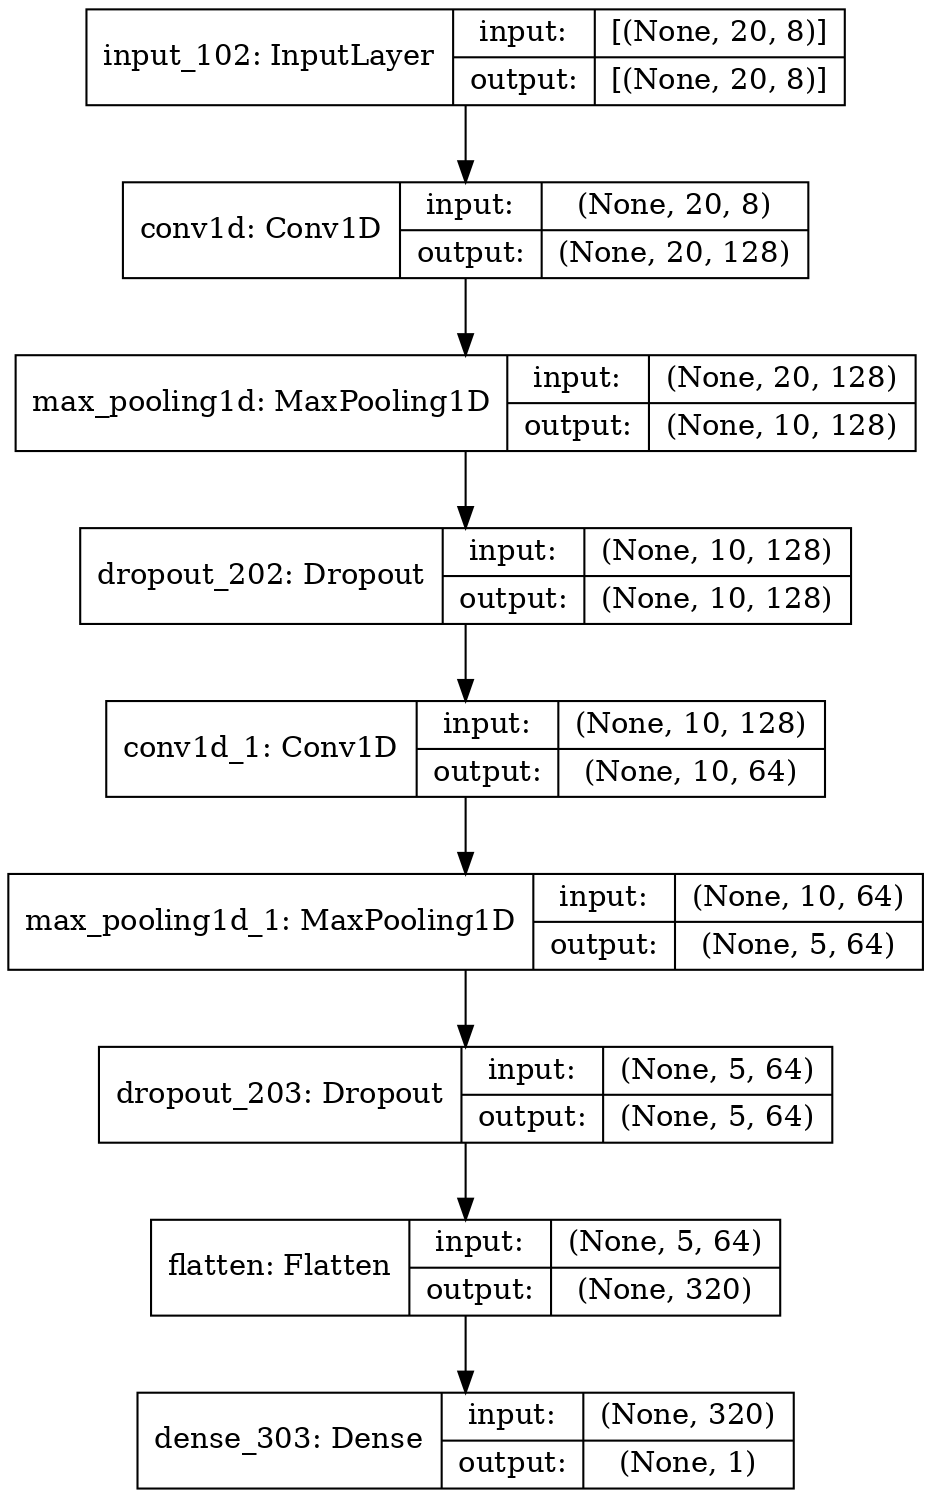

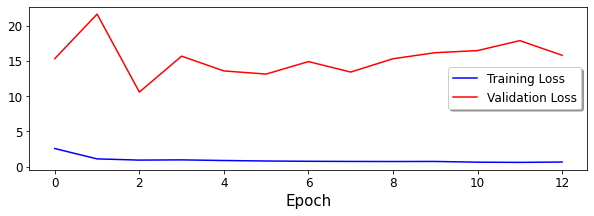

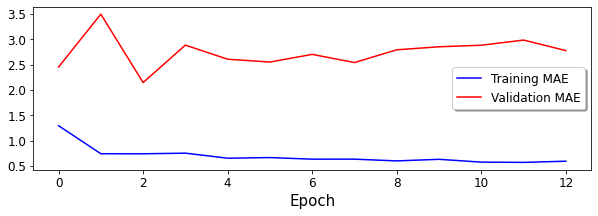

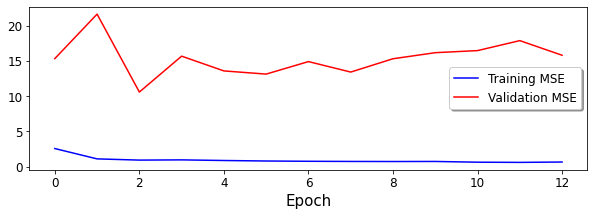

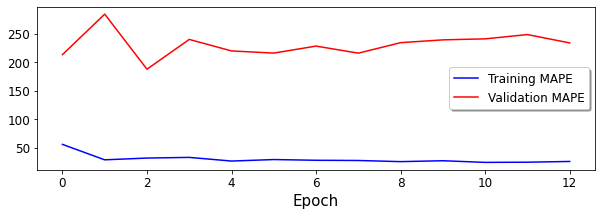

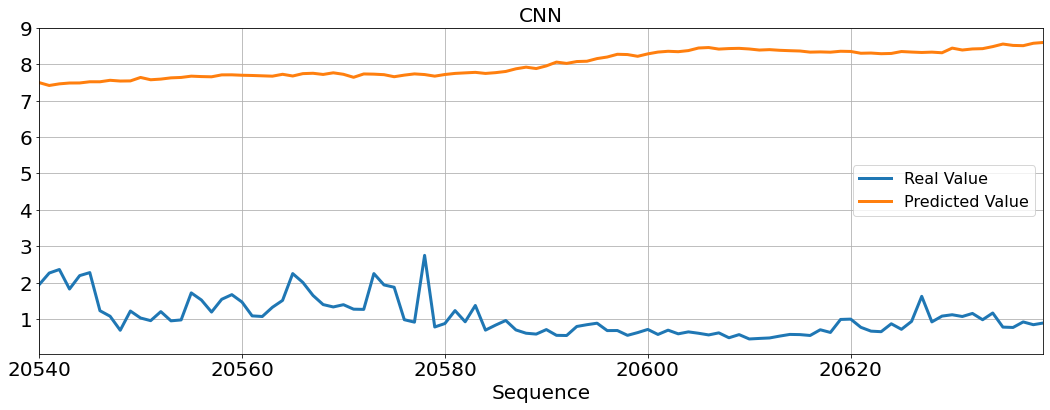

,MAE,MSE,MAPE
Score,6.93,48.65,8.13


In [6]:
# Data Loading
raw = fetch_california_housing()
df_X = pd.DataFrame(raw.data, columns=raw.feature_names)
df_Y = pd.DataFrame(raw.target, columns=['Price'])
df = pd.concat([df_Y, df_X], axis=1)
df = df[-500:].copy()

# Data Split and Scaling
X_train, Y_train, X_val, Y_val, X_test, Y_test = \
dl_preprocessing(df, Y_colname, TEST_SIZE=TEST_SIZE, SCALER=SCALER, 
                 CONVERT_SEQ=True, SEQUENCE=SEQUENCE)

# CNN
algo_CNN = dl_CNN(X_train, OUTPUT, ACTIVATION='relu', DROPOUT_RATIO=DROPOUT_RATIO)
dl_show_structure(algo_CNN, RESULT_LOCATION=RESULT_LOCATION, 
                  RESULT_NAME='CNN.png', RESULT_DPI=150)

# Learning
algo_CNN, algo_CNNfit = dl_learning_reg(algo_CNN, X_train, Y_train, X_val, Y_val,
                                        OPTIMIZER=OPTIMIZER, 
                                        BATCH_SIZE=BATCH_SIZE, EPOCHS=EPOCHS,
                                        CALLBACK_TYPE=CALLBACK_TYPE, EARLYSTOP_PATIENT=EARLYSTOP_PATIENT,
                                        VERBOSE=VERBOSE, 
                                        RESULT_LOCATION=RESULT_LOCATION, RESULT_NAME='CNN.h5')
evaluation_reg_LearningPlot(algo_CNNfit)

# Prediction
Y_pred = algo_CNN.predict(X_test)
Y_pred = pd.DataFrame(Y_pred, index=Y_test.index, columns=Y_colname)

# Evaluation
evaluation_reg_PredPlot(Y_test, Y_pred, title='CNN', ylabel='')
Score, Resid_te = evaluation_reg_MAE_MSE_MAPE(Y_test, Y_pred)
display(Score)

# Summary
Score_CNN = Score.copy()
Y_pred_CNN = Y_pred.copy()

### Walk Forward

 99%|█████████▉| 99/100 [03:27<00:02,  2.16s/it]

Model: "model_201"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_202 (InputLayer)       [(None, 20, 8)]           0         
_________________________________________________________________
conv1d_200 (Conv1D)          (None, 20, 128)           20608     
_________________________________________________________________
max_pooling1d_200 (MaxPoolin (None, 10, 128)           0         
_________________________________________________________________
dropout_402 (Dropout)        (None, 10, 128)           0         
_________________________________________________________________
conv1d_201 (Conv1D)          (None, 10, 64)            163904    
_________________________________________________________________
max_pooling1d_201 (MaxPoolin (None, 5, 64)             0         
_________________________________________________________________
dropout_403 (Dropout)        (None, 5, 64)             0 

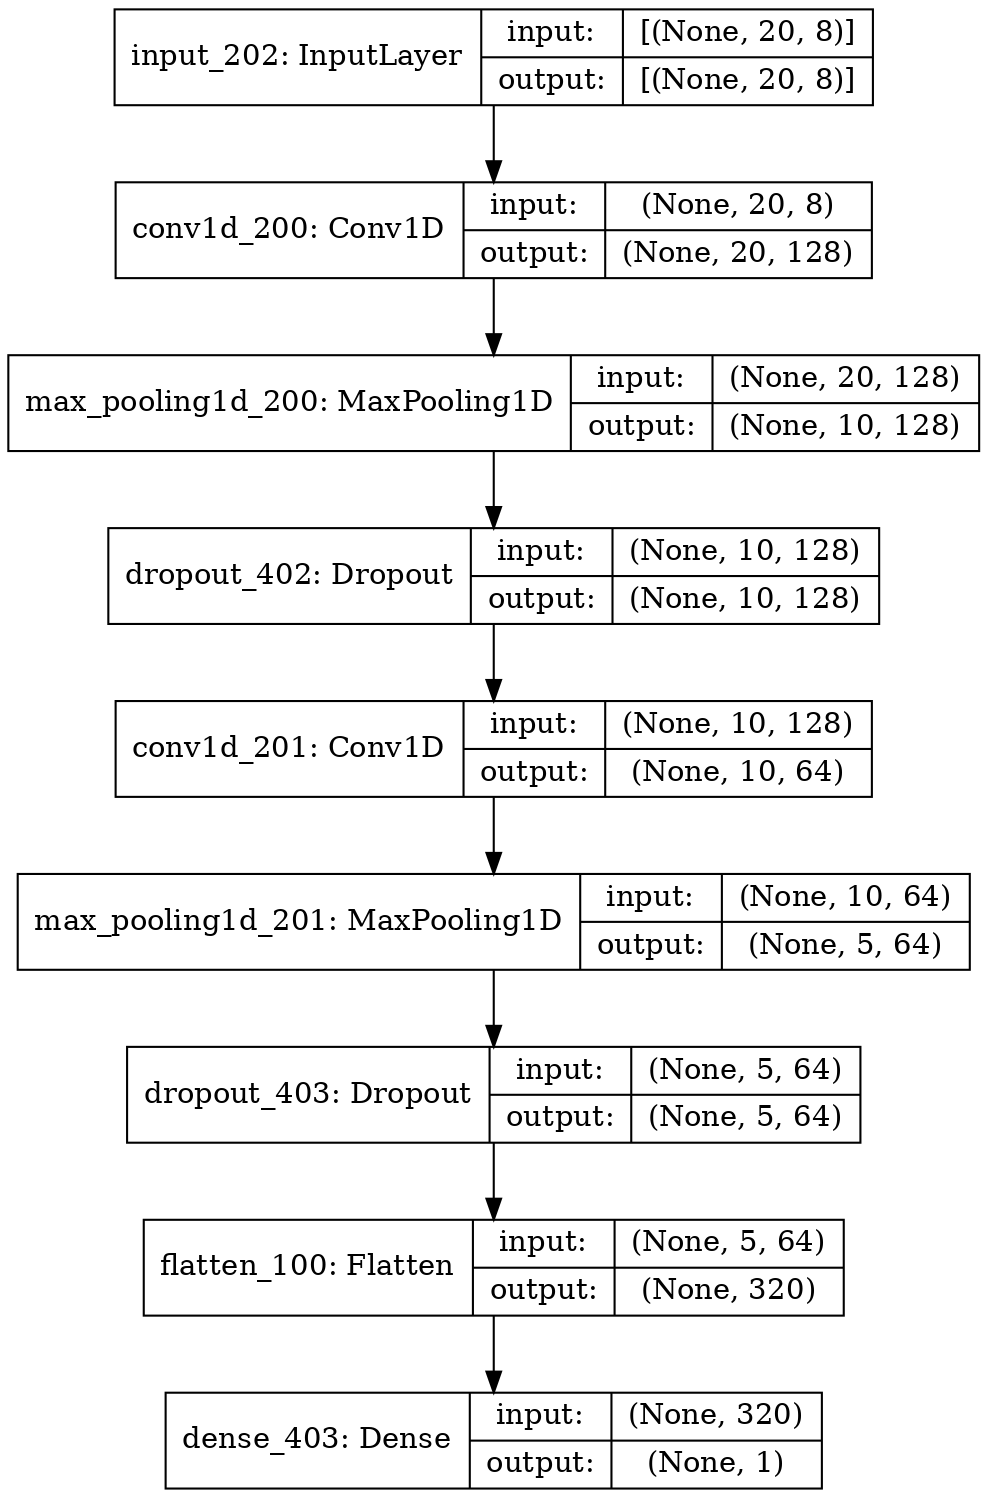

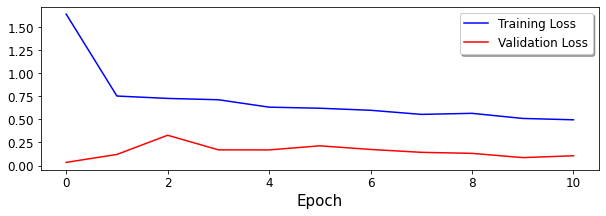

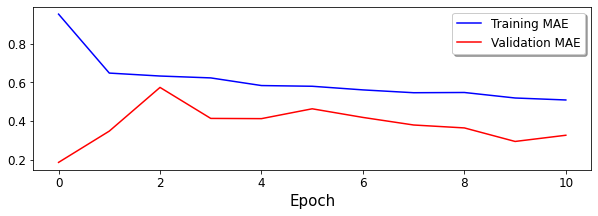

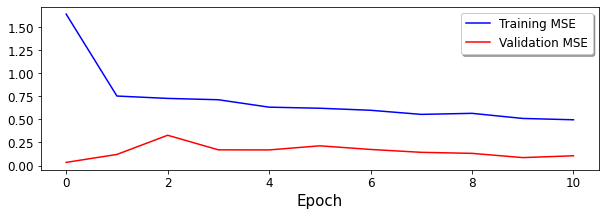

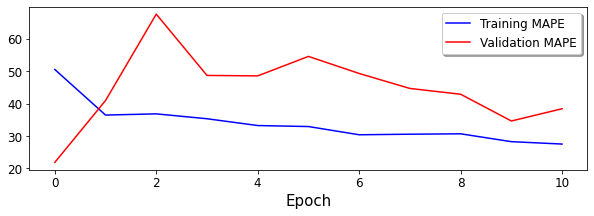

100%|██████████| 100/100 [03:29<00:00,  2.10s/it]


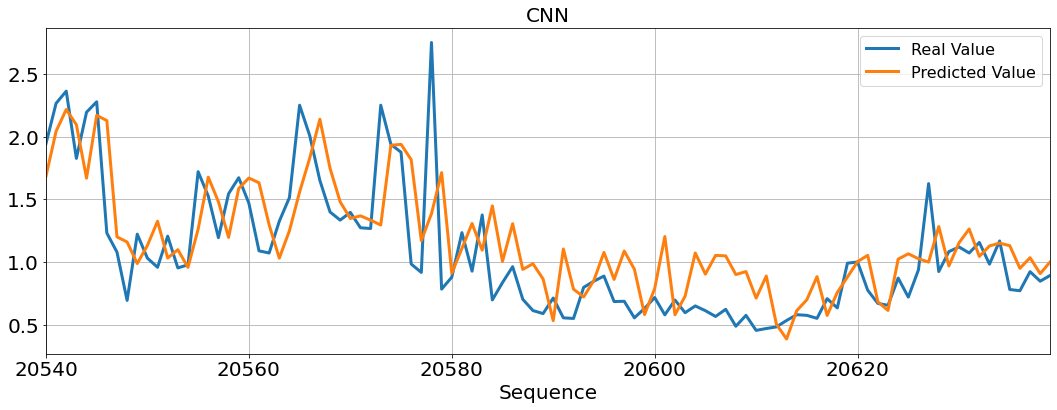

,MAE,MSE,MAPE
Score,0.27,0.13,0.30


In [7]:
# Data Loading
raw = fetch_california_housing()
df_X = pd.DataFrame(raw.data, columns=raw.feature_names)
df_Y = pd.DataFrame(raw.target, columns=['Price'])
df = pd.concat([df_Y, df_X], axis=1)
df = df[-500:].copy()

# Modeling
Y_real, Y_pred = pd.DataFrame(), pd.DataFrame()
spliter = TimeSeriesSplit(gap=0, n_splits=TEST_SIZE, test_size=OUTPUT)
for idx, (train_index, test_index) in tqdm(enumerate(spliter.split(df)), total=TEST_SIZE):
    # Data Split and Scaling
    X_train, Y_train, X_val, Y_val, X_test, Y_test = \
    dl_preprocessing_walkforward(df, Y_colname, train_index, test_index, 
                                 VAL_SIZE=OUTPUT, SCALER=SCALER, 
                                 CONVERT_SEQ=True, SEQUENCE=SEQUENCE)

    # CNN
    algo_CNN = dl_CNN(X_train, 1, ACTIVATION='relu', DROPOUT_RATIO=DROPOUT_RATIO)
    if (idx+1) == TEST_SIZE:
        dl_show_structure(algo_CNN, RESULT_LOCATION=RESULT_LOCATION, 
                          RESULT_NAME='CNN_Forward.png', RESULT_DPI=150)
    
    # Learning
    algo_CNN, algo_CNNfit = dl_learning_reg(algo_CNN, X_train, Y_train, X_val, Y_val,
                                            OPTIMIZER=OPTIMIZER, 
                                            BATCH_SIZE=BATCH_SIZE, EPOCHS=EPOCHS,
                                            CALLBACK_TYPE=CALLBACK_TYPE, EARLYSTOP_PATIENT=EARLYSTOP_PATIENT,
                                            VERBOSE=VERBOSE, 
                                            RESULT_LOCATION=RESULT_LOCATION, RESULT_NAME='CNN_Forward.h5')
    if (idx+1) == TEST_SIZE:
        evaluation_reg_LearningPlot(algo_CNNfit)
    
    # Prediction
    Y_tepred = algo_CNN.predict(X_test)
    
    # Rearrange
    Y_real = pd.concat([Y_real, Y_test], axis=0)
    Y_pred = pd.concat([Y_pred, pd.DataFrame(Y_tepred, index=Y_test.index,
                                             columns=Y_test.columns)], axis=0)
    
# Evaluation
evaluation_reg_PredPlot(Y_real, Y_pred, title='CNN', ylabel='')
Score, Resid_te = evaluation_reg_MAE_MSE_MAPE(Y_real, Y_pred)
display(Score)

# Summary
Score_CNN = Score.copy()
Y_pred_CNN = Y_pred.copy()

## RNN

Trasformed:
X_train: (281, 20, 8) Y_train: (281, 1)
X_val: (100, 20, 8) Y_val: (100, 1)
X_test: (100, 20, 8) Y_test: (100, 1)
Model: "model_202"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_203 (InputLayer)       [(None, 20, 8)]           0         
_________________________________________________________________
simple_rnn (SimpleRNN)       (None, 20, 128)           17536     
_________________________________________________________________
dropout_404 (Dropout)        (None, 20, 128)           0         
_________________________________________________________________
simple_rnn_1 (SimpleRNN)     (None, 20, 64)            12352     
_________________________________________________________________
dropout_405 (Dropout)        (None, 20, 64)            0         
_________________________________________________________________
flatten_101 (Flatten)        (None, 1280)              0       

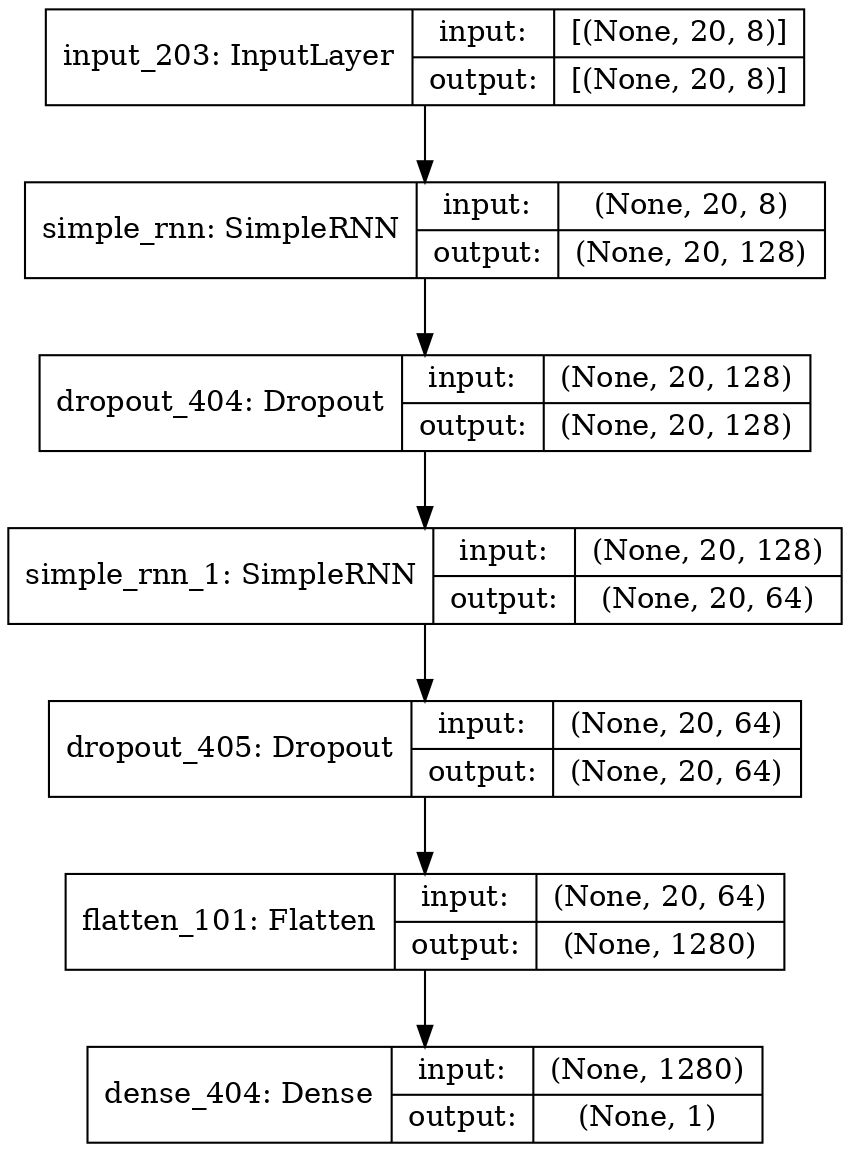

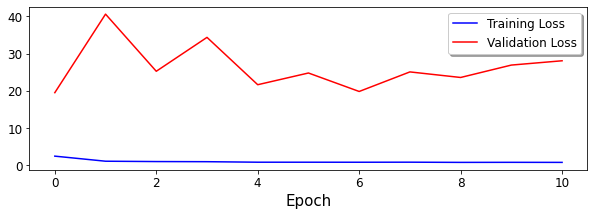

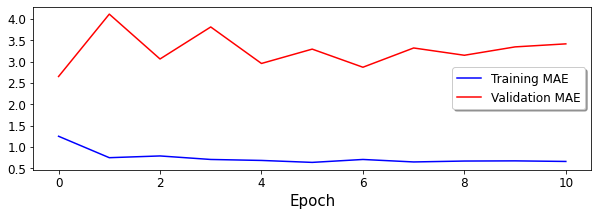

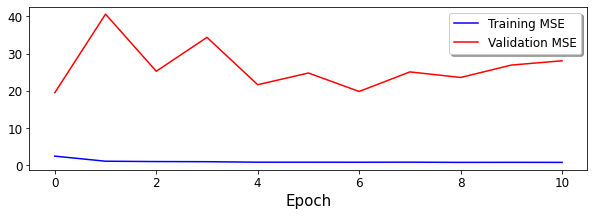

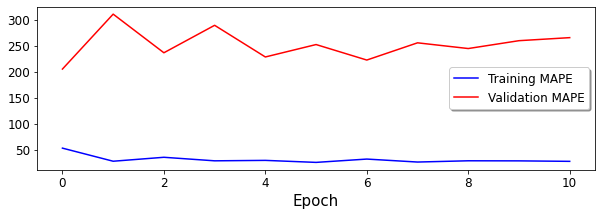

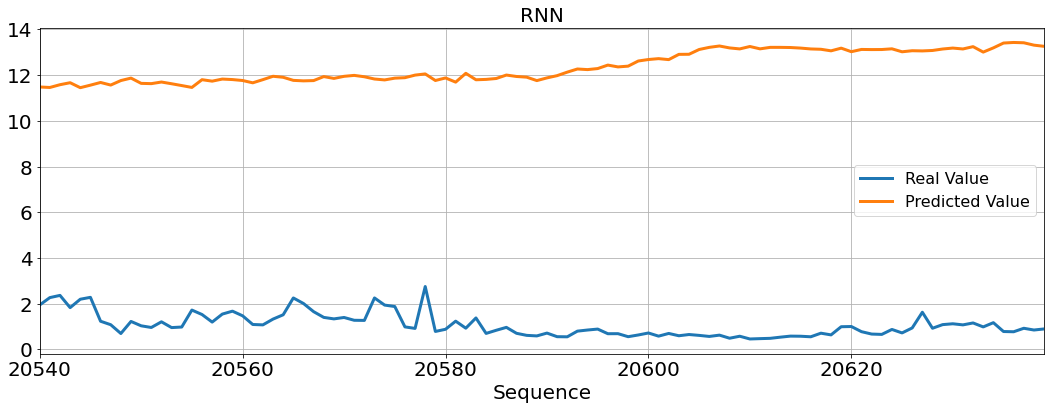

,MAE,MSE,MAPE
Score,11.29,128.59,13.12


In [8]:
# Data Loading
raw = fetch_california_housing()
df_X = pd.DataFrame(raw.data, columns=raw.feature_names)
df_Y = pd.DataFrame(raw.target, columns=['Price'])
df = pd.concat([df_Y, df_X], axis=1)
df = df[-500:].copy()

# Data Split and Scaling
X_train, Y_train, X_val, Y_val, X_test, Y_test = \
dl_preprocessing(df, Y_colname, TEST_SIZE=TEST_SIZE, SCALER=SCALER, 
                 CONVERT_SEQ=True, SEQUENCE=SEQUENCE)

# RNN
algo_RNN = dl_RNN(X_train, OUTPUT, ACTIVATION='relu', DROPOUT_RATIO=DROPOUT_RATIO)
dl_show_structure(algo_RNN, RESULT_LOCATION=RESULT_LOCATION, 
                  RESULT_NAME='RNN.png', RESULT_DPI=150)

# Learning
algo_RNN, algo_RNNfit = dl_learning_reg(algo_RNN, X_train, Y_train, X_val, Y_val,
                                        OPTIMIZER=OPTIMIZER, 
                                        BATCH_SIZE=BATCH_SIZE, EPOCHS=EPOCHS,
                                        CALLBACK_TYPE=CALLBACK_TYPE, EARLYSTOP_PATIENT=EARLYSTOP_PATIENT,
                                        VERBOSE=VERBOSE, 
                                        RESULT_LOCATION=RESULT_LOCATION, RESULT_NAME='RNN.h5')
evaluation_reg_LearningPlot(algo_RNNfit)

# Prediction
Y_pred = algo_RNN.predict(X_test)
Y_pred = pd.DataFrame(Y_pred, index=Y_test.index, columns=Y_colname)

# Evaluation
evaluation_reg_PredPlot(Y_test, Y_pred, title='RNN', ylabel='')
Score, Resid_te = evaluation_reg_MAE_MSE_MAPE(Y_test, Y_pred)
display(Score)

# Summary
Score_RNN = Score.copy()
Y_pred_RNN = Y_pred.copy()

### Walk Forward

 99%|█████████▉| 99/100 [16:11<00:10, 10.29s/it]

Model: "model_302"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_303 (InputLayer)       [(None, 20, 8)]           0         
_________________________________________________________________
simple_rnn_200 (SimpleRNN)   (None, 20, 128)           17536     
_________________________________________________________________
dropout_604 (Dropout)        (None, 20, 128)           0         
_________________________________________________________________
simple_rnn_201 (SimpleRNN)   (None, 20, 64)            12352     
_________________________________________________________________
dropout_605 (Dropout)        (None, 20, 64)            0         
_________________________________________________________________
flatten_201 (Flatten)        (None, 1280)              0         
_________________________________________________________________
dense_504 (Dense)            (None, 1)                 12

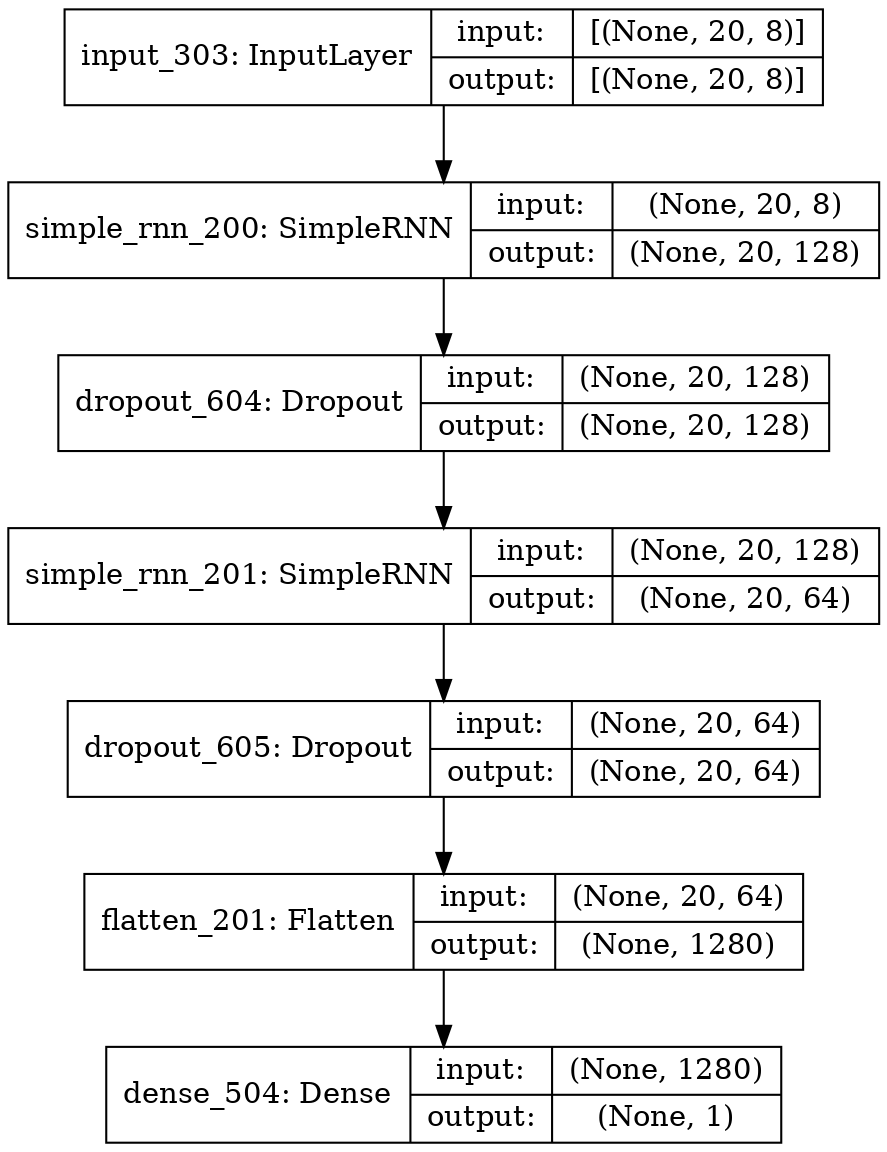

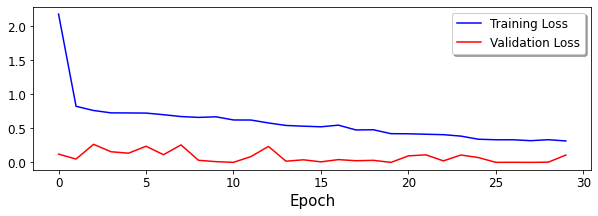

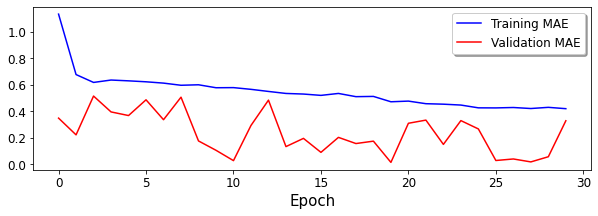

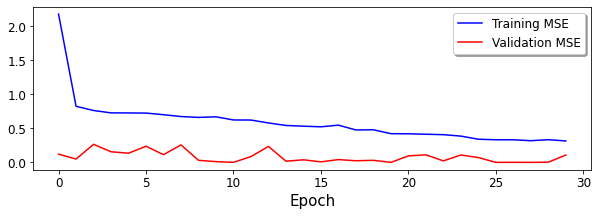

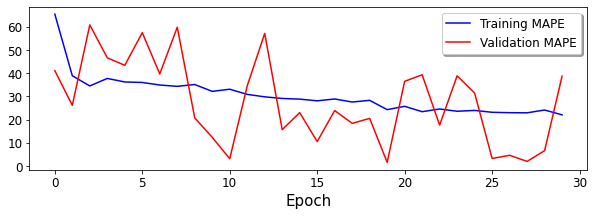

100%|██████████| 100/100 [16:25<00:00,  9.86s/it]


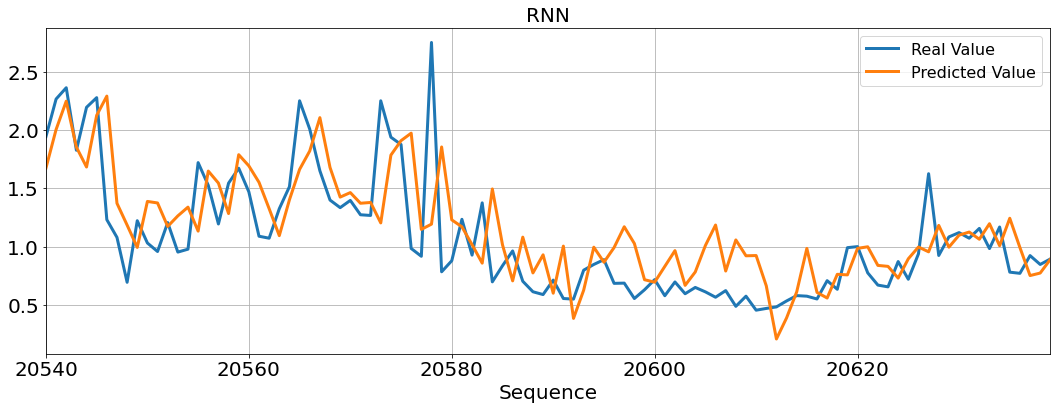

,MAE,MSE,MAPE
Score,0.28,0.15,0.31


In [9]:
# Data Loading
raw = fetch_california_housing()
df_X = pd.DataFrame(raw.data, columns=raw.feature_names)
df_Y = pd.DataFrame(raw.target, columns=['Price'])
df = pd.concat([df_Y, df_X], axis=1)
df = df[-500:].copy()

# Modeling
Y_real, Y_pred = pd.DataFrame(), pd.DataFrame()
spliter = TimeSeriesSplit(gap=0, n_splits=TEST_SIZE, test_size=OUTPUT)
for idx, (train_index, test_index) in tqdm(enumerate(spliter.split(df)), total=TEST_SIZE):
    # Data Split and Scaling
    X_train, Y_train, X_val, Y_val, X_test, Y_test = \
    dl_preprocessing_walkforward(df, Y_colname, train_index, test_index, 
                                 VAL_SIZE=OUTPUT, SCALER=SCALER, 
                                 CONVERT_SEQ=True, SEQUENCE=SEQUENCE)
    
    # RNN
    algo_RNN = dl_RNN(X_train, 1, ACTIVATION='relu', DROPOUT_RATIO=DROPOUT_RATIO)
    if (idx+1) == TEST_SIZE:
        dl_show_structure(algo_RNN, RESULT_LOCATION=RESULT_LOCATION, 
                          RESULT_NAME='RNN_Forward.png', RESULT_DPI=150)
    
    # Learning
    algo_RNN, algo_RNNfit = dl_learning_reg(algo_RNN, X_train, Y_train, X_val, Y_val,
                                            OPTIMIZER=OPTIMIZER, 
                                            BATCH_SIZE=BATCH_SIZE, EPOCHS=EPOCHS,
                                            CALLBACK_TYPE=CALLBACK_TYPE, EARLYSTOP_PATIENT=EARLYSTOP_PATIENT,
                                            VERBOSE=VERBOSE, 
                                            RESULT_LOCATION=RESULT_LOCATION, RESULT_NAME='RNN_Forward.h5')
    if (idx+1) == TEST_SIZE:
        evaluation_reg_LearningPlot(algo_RNNfit)
    
    # Prediction
    Y_tepred = algo_RNN.predict(X_test)
    
    # Rearrange
    Y_real = pd.concat([Y_real, Y_test], axis=0)
    Y_pred = pd.concat([Y_pred, pd.DataFrame(Y_tepred, index=Y_test.index,
                                             columns=Y_test.columns)], axis=0)
    
# Evaluation
evaluation_reg_PredPlot(Y_real, Y_pred, title='RNN', ylabel='')
Score, Resid_te = evaluation_reg_MAE_MSE_MAPE(Y_real, Y_pred)
display(Score)

# Summary
Score_RNN = Score.copy()
Y_pred_RNN = Y_pred.copy()

## LSTM

Trasformed:
X_train: (281, 20, 8) Y_train: (281, 1)
X_val: (100, 20, 8) Y_val: (100, 1)
X_test: (100, 20, 8) Y_test: (100, 1)
Model: "model_303"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_304 (InputLayer)       [(None, 20, 8)]           0         
_________________________________________________________________
lstm (LSTM)                  (None, 20, 128)           70144     
_________________________________________________________________
dropout_606 (Dropout)        (None, 20, 128)           0         
_________________________________________________________________
lstm_1 (LSTM)                (None, 64)                49408     
_________________________________________________________________
dropout_607 (Dropout)        (None, 64)                0         
_________________________________________________________________
dense_505 (Dense)            (None, 1)                 65      

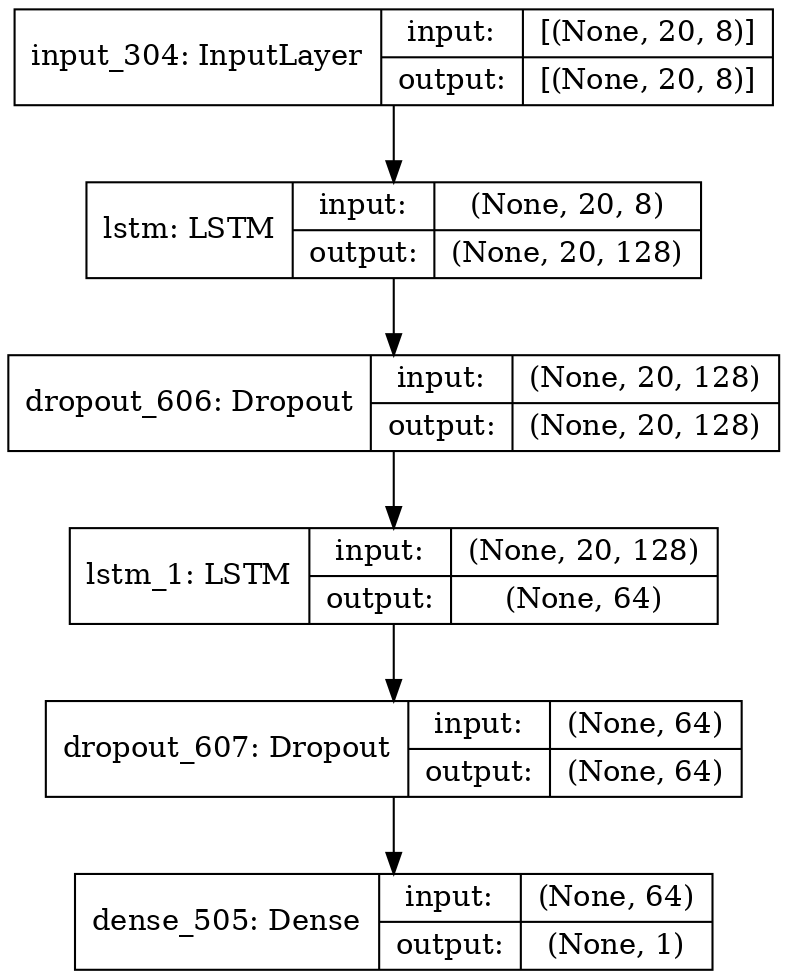

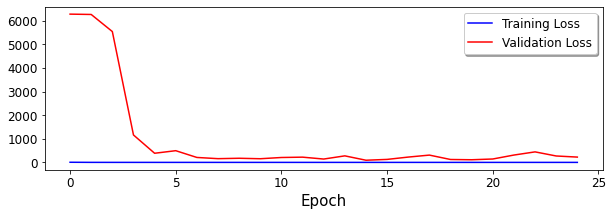

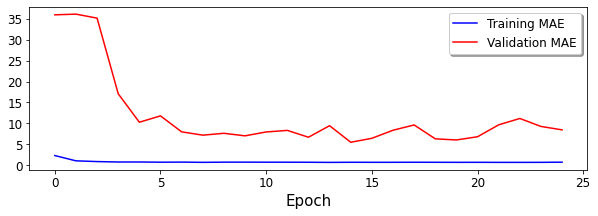

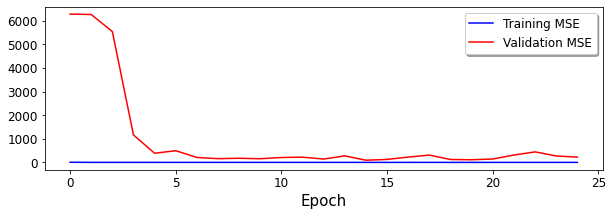

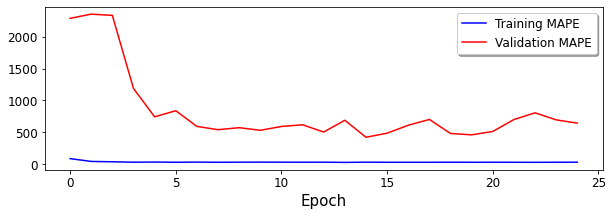

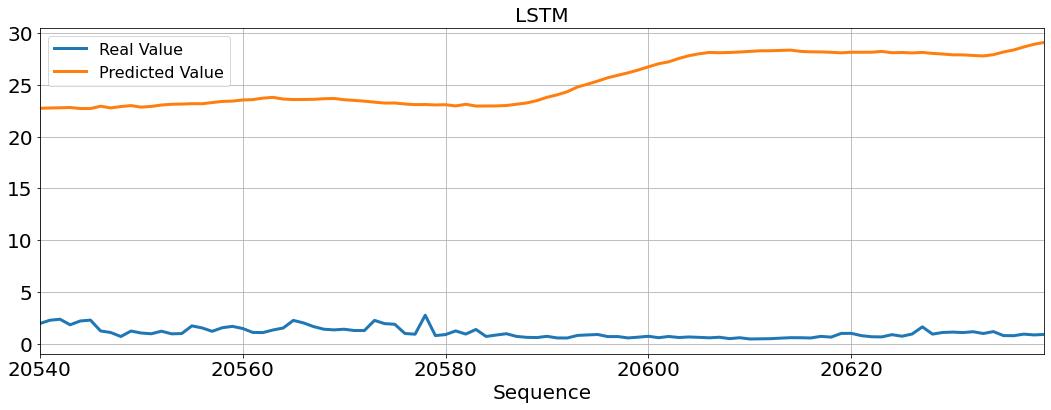

,MAE,MSE,MAPE
Score,24.28,596.50,28.20


In [10]:
# Data Loading
raw = fetch_california_housing()
df_X = pd.DataFrame(raw.data, columns=raw.feature_names)
df_Y = pd.DataFrame(raw.target, columns=['Price'])
df = pd.concat([df_Y, df_X], axis=1)
df = df[-500:].copy()

# Data Split and Scaling
X_train, Y_train, X_val, Y_val, X_test, Y_test = \
dl_preprocessing(df, Y_colname, TEST_SIZE=TEST_SIZE, SCALER=SCALER, 
                 CONVERT_SEQ=True, SEQUENCE=SEQUENCE)

# LSTM
algo_LSTM = dl_LSTM(X_train, OUTPUT, ACTIVATION='relu', DROPOUT_RATIO=DROPOUT_RATIO)
dl_show_structure(algo_LSTM, RESULT_LOCATION=RESULT_LOCATION, 
                  RESULT_NAME='LSTM.png', RESULT_DPI=150)

# Learning
algo_LSTM, algo_LSTMfit = dl_learning_reg(algo_LSTM, X_train, Y_train, X_val, Y_val,
                                        OPTIMIZER=OPTIMIZER, 
                                        BATCH_SIZE=BATCH_SIZE, EPOCHS=EPOCHS,
                                        CALLBACK_TYPE=CALLBACK_TYPE, EARLYSTOP_PATIENT=EARLYSTOP_PATIENT,
                                        VERBOSE=VERBOSE, 
                                        RESULT_LOCATION=RESULT_LOCATION, RESULT_NAME='LSTM.h5')
evaluation_reg_LearningPlot(algo_LSTMfit)

# Prediction
Y_pred = algo_LSTM.predict(X_test)
Y_pred = pd.DataFrame(Y_pred, index=Y_test.index, columns=Y_colname)

# Evaluation
evaluation_reg_PredPlot(Y_test, Y_pred, title='LSTM', ylabel='')
Score, Resid_te = evaluation_reg_MAE_MSE_MAPE(Y_test, Y_pred)
display(Score)

# Summary
Score_LSTM = Score.copy()
Y_pred_LSTM = Y_pred.copy()

### Walk Forward

 99%|█████████▉| 99/100 [28:39<00:15, 15.49s/it]

Model: "model_403"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_404 (InputLayer)       [(None, 20, 8)]           0         
_________________________________________________________________
lstm_200 (LSTM)              (None, 20, 128)           70144     
_________________________________________________________________
dropout_806 (Dropout)        (None, 20, 128)           0         
_________________________________________________________________
lstm_201 (LSTM)              (None, 64)                49408     
_________________________________________________________________
dropout_807 (Dropout)        (None, 64)                0         
_________________________________________________________________
dense_605 (Dense)            (None, 1)                 65        
Total params: 119,617
Trainable params: 119,617
Non-trainable params: 0
___________________________________________________

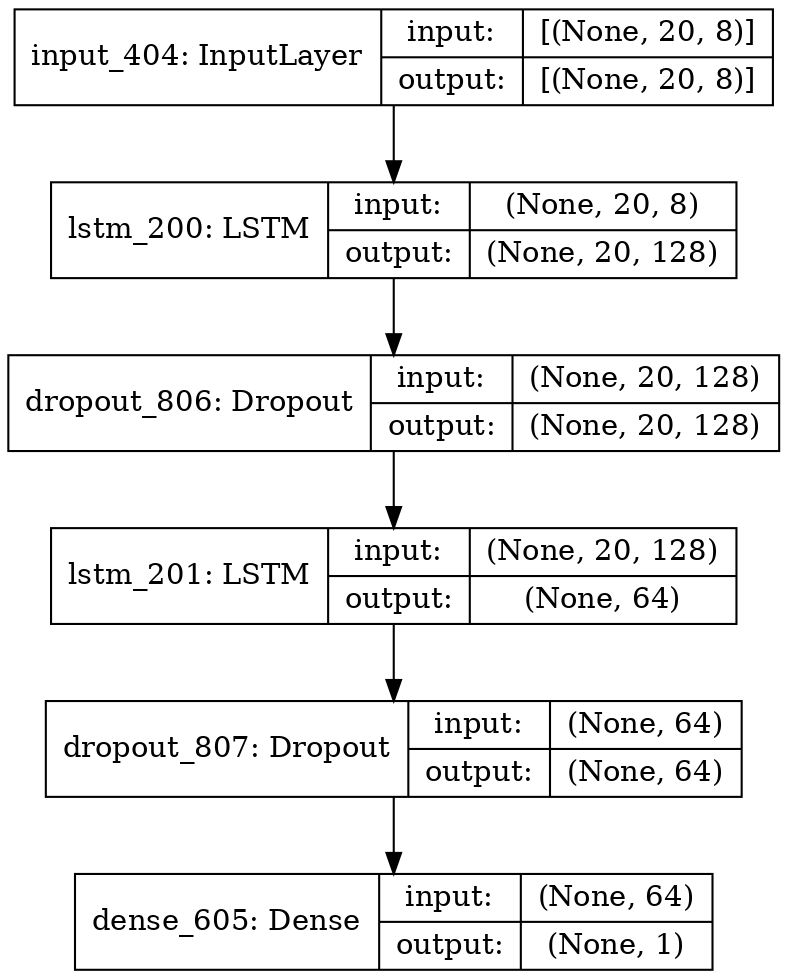

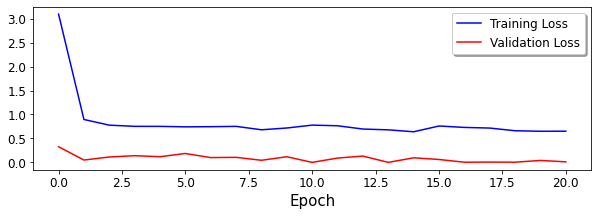

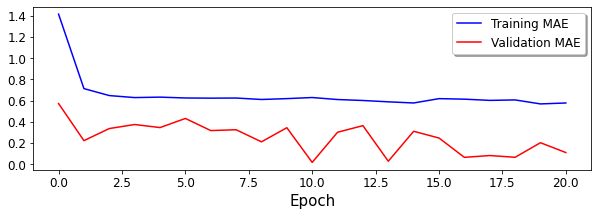

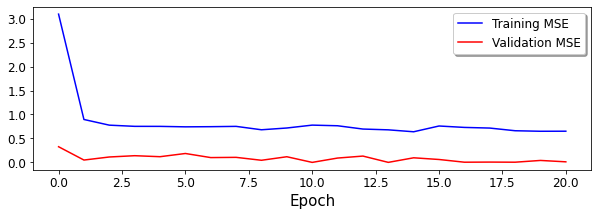

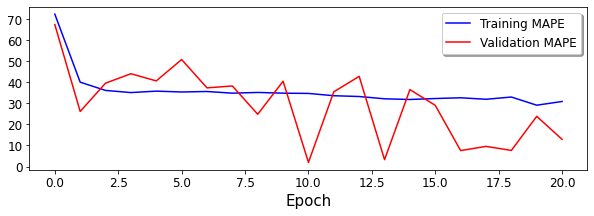

100%|██████████| 100/100 [28:58<00:00, 17.38s/it]


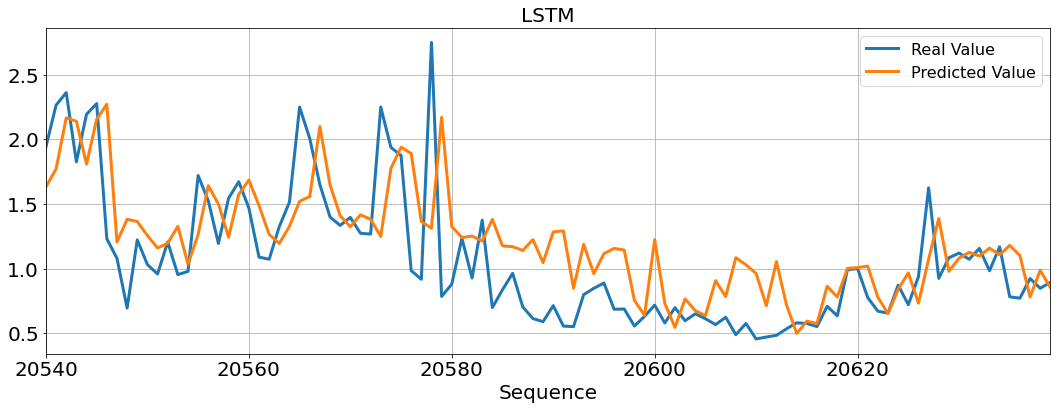

,MAE,MSE,MAPE
Score,0.30,0.16,0.33


In [11]:
# Data Loading
raw = fetch_california_housing()
df_X = pd.DataFrame(raw.data, columns=raw.feature_names)
df_Y = pd.DataFrame(raw.target, columns=['Price'])
df = pd.concat([df_Y, df_X], axis=1)
df = df[-500:].copy()

# Modeling
Y_real, Y_pred = pd.DataFrame(), pd.DataFrame()
spliter = TimeSeriesSplit(gap=0, n_splits=TEST_SIZE, test_size=OUTPUT)
for idx, (train_index, test_index) in tqdm(enumerate(spliter.split(df)), total=TEST_SIZE):
    # Data Split and Scaling
    X_train, Y_train, X_val, Y_val, X_test, Y_test = \
    dl_preprocessing_walkforward(df, Y_colname, train_index, test_index, 
                                 VAL_SIZE=OUTPUT, SCALER=SCALER, 
                                 CONVERT_SEQ=True, SEQUENCE=SEQUENCE)
    
    # LSTM
    algo_LSTM = dl_LSTM(X_train, 1, ACTIVATION='relu', DROPOUT_RATIO=DROPOUT_RATIO)
    if (idx+1) == TEST_SIZE:
        dl_show_structure(algo_LSTM, RESULT_LOCATION=RESULT_LOCATION, 
                          RESULT_NAME='LSTM_Forward.png', RESULT_DPI=150)
    
    # Learning
    algo_LSTM, algo_LSTMfit = dl_learning_reg(algo_LSTM, X_train, Y_train, X_val, Y_val,
                                              OPTIMIZER=OPTIMIZER, 
                                              BATCH_SIZE=BATCH_SIZE, EPOCHS=EPOCHS,
                                              CALLBACK_TYPE=CALLBACK_TYPE, EARLYSTOP_PATIENT=EARLYSTOP_PATIENT,
                                              VERBOSE=VERBOSE, 
                                              RESULT_LOCATION=RESULT_LOCATION, RESULT_NAME='LSTM_Forward.h5')
    if (idx+1) == TEST_SIZE:
        evaluation_reg_LearningPlot(algo_LSTMfit)
    
    # Prediction
    Y_tepred = algo_LSTM.predict(X_test)
    
    # Rearrange
    Y_real = pd.concat([Y_real, Y_test], axis=0)
    Y_pred = pd.concat([Y_pred, pd.DataFrame(Y_tepred, index=Y_test.index,
                                             columns=Y_test.columns)], axis=0)
    
# Evaluation
evaluation_reg_PredPlot(Y_real, Y_pred, title='LSTM', ylabel='')
Score, Resid_te = evaluation_reg_MAE_MSE_MAPE(Y_real, Y_pred)
display(Score)

# Summary
Score_LSTM = Score.copy()
Y_pred_LSTM = Y_pred.copy()

## GRU

Trasformed:
X_train: (281, 20, 8) Y_train: (281, 1)
X_val: (100, 20, 8) Y_val: (100, 1)
X_test: (100, 20, 8) Y_test: (100, 1)
Model: "model_404"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_405 (InputLayer)       [(None, 20, 8)]           0         
_________________________________________________________________
gru (GRU)                    (None, 20, 128)           52992     
_________________________________________________________________
dropout_808 (Dropout)        (None, 20, 128)           0         
_________________________________________________________________
gru_1 (GRU)                  (None, 64)                37248     
_________________________________________________________________
dropout_809 (Dropout)        (None, 64)                0         
_________________________________________________________________
dense_606 (Dense)            (None, 1)                 65      

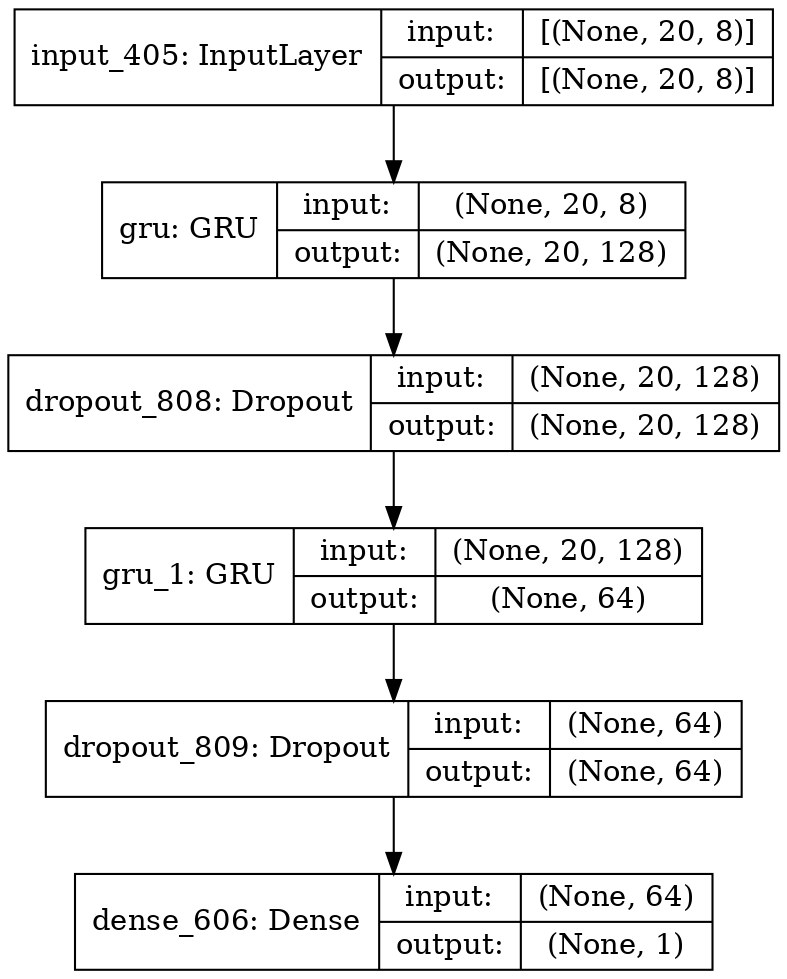

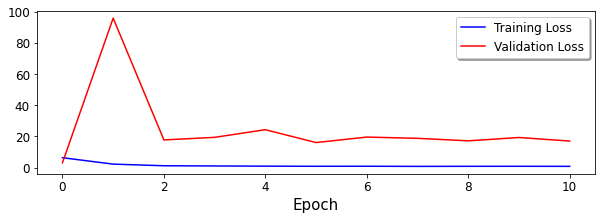

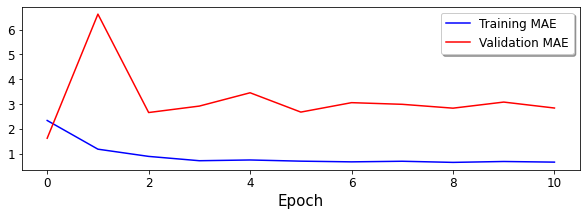

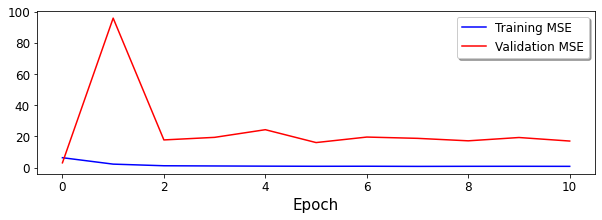

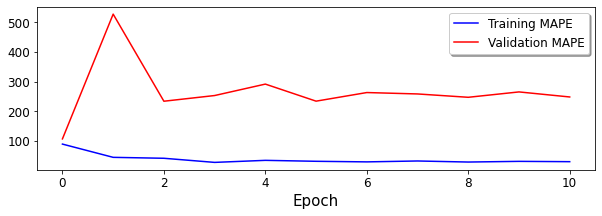

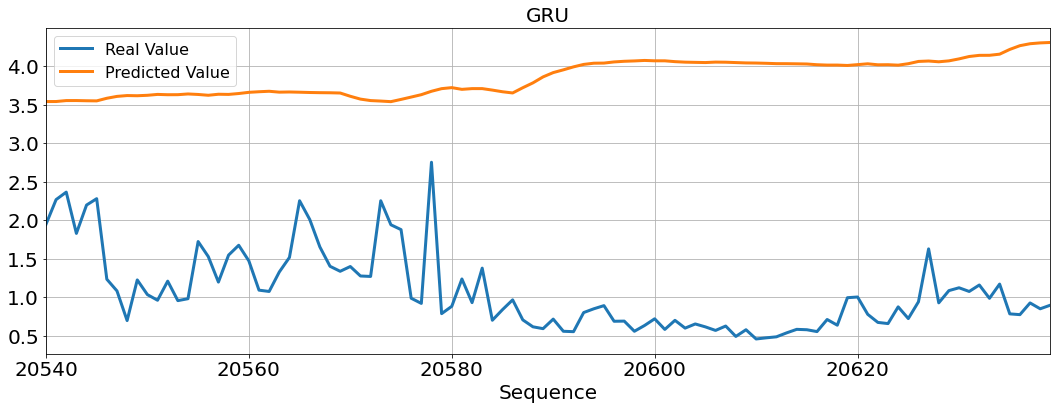

,MAE,MSE,MAPE
Score,2.78,8.18,3.41


In [12]:
# Data Loading
raw = fetch_california_housing()
df_X = pd.DataFrame(raw.data, columns=raw.feature_names)
df_Y = pd.DataFrame(raw.target, columns=['Price'])
df = pd.concat([df_Y, df_X], axis=1)
df = df[-500:].copy()

# Data Split and Scaling
X_train, Y_train, X_val, Y_val, X_test, Y_test = \
dl_preprocessing(df, Y_colname, TEST_SIZE=TEST_SIZE, SCALER=SCALER, 
                 CONVERT_SEQ=True, SEQUENCE=SEQUENCE)

# GRU
algo_GRU = dl_GRU(X_train, OUTPUT, ACTIVATION='relu', DROPOUT_RATIO=DROPOUT_RATIO)
dl_show_structure(algo_GRU, RESULT_LOCATION=RESULT_LOCATION, 
                  RESULT_NAME='GRU.png', RESULT_DPI=150)

# Learning
algo_GRU, algo_GRUfit = dl_learning_reg(algo_GRU, X_train, Y_train, X_val, Y_val,
                                        OPTIMIZER=OPTIMIZER, 
                                        BATCH_SIZE=BATCH_SIZE, EPOCHS=EPOCHS,
                                        CALLBACK_TYPE=CALLBACK_TYPE, EARLYSTOP_PATIENT=EARLYSTOP_PATIENT,
                                        VERBOSE=VERBOSE, 
                                        RESULT_LOCATION=RESULT_LOCATION, RESULT_NAME='GRU.h5')
evaluation_reg_LearningPlot(algo_GRUfit)

# Prediction
Y_pred = algo_GRU.predict(X_test)
Y_pred = pd.DataFrame(Y_pred, index=Y_test.index, columns=Y_colname)

# Evaluation
evaluation_reg_PredPlot(Y_test, Y_pred, title='GRU', ylabel='')
Score, Resid_te = evaluation_reg_MAE_MSE_MAPE(Y_test, Y_pred)
display(Score)

# Summary
Score_GRU = Score.copy()
Y_pred_GRU = Y_pred.copy()

### Walk Forward

 99%|█████████▉| 99/100 [36:53<00:27, 27.58s/it]

Model: "model_504"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_505 (InputLayer)       [(None, 20, 8)]           0         
_________________________________________________________________
gru_200 (GRU)                (None, 20, 128)           52992     
_________________________________________________________________
dropout_1008 (Dropout)       (None, 20, 128)           0         
_________________________________________________________________
gru_201 (GRU)                (None, 64)                37248     
_________________________________________________________________
dropout_1009 (Dropout)       (None, 64)                0         
_________________________________________________________________
dense_706 (Dense)            (None, 1)                 65        
Total params: 90,305
Trainable params: 90,305
Non-trainable params: 0
_____________________________________________________

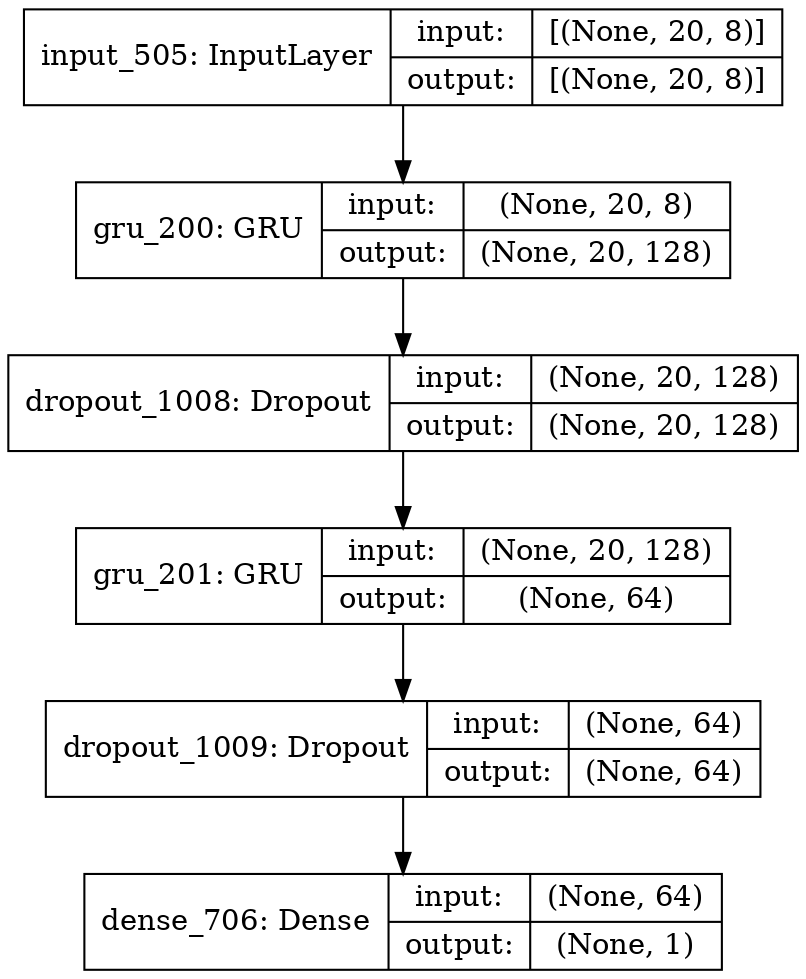

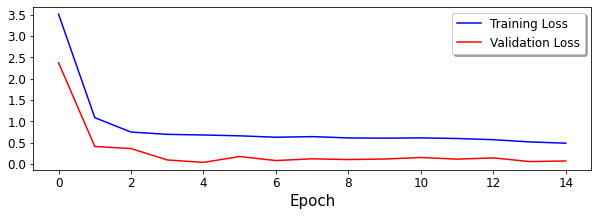

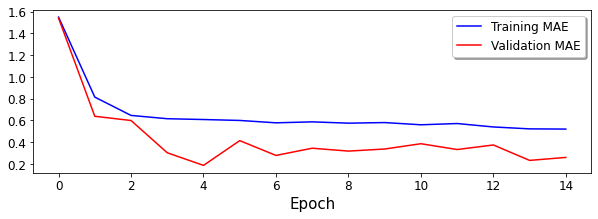

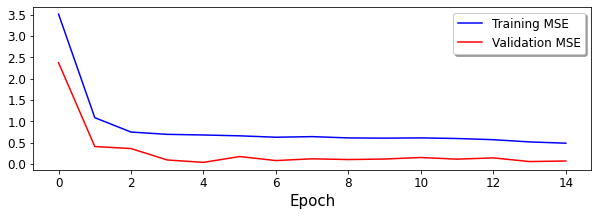

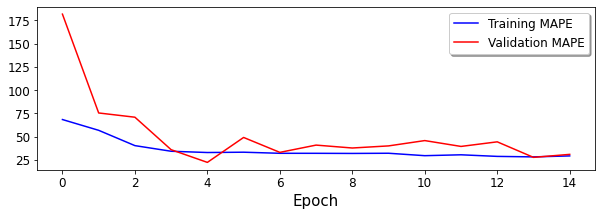

100%|██████████| 100/100 [37:10<00:00, 22.30s/it]


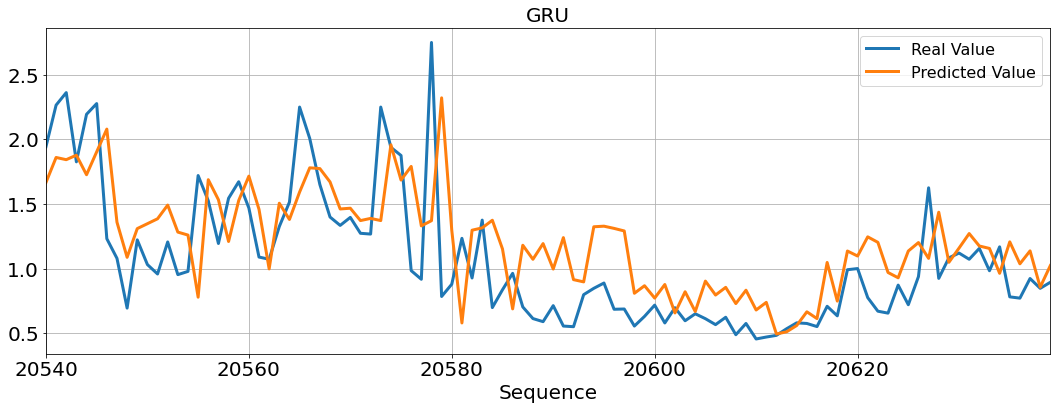

,MAE,MSE,MAPE
Score,0.32,0.17,0.34


In [13]:
# Data Loading
raw = fetch_california_housing()
df_X = pd.DataFrame(raw.data, columns=raw.feature_names)
df_Y = pd.DataFrame(raw.target, columns=['Price'])
df = pd.concat([df_Y, df_X], axis=1)
df = df[-500:].copy()

# Modeling
Y_real, Y_pred = pd.DataFrame(), pd.DataFrame()
spliter = TimeSeriesSplit(gap=0, n_splits=TEST_SIZE, test_size=OUTPUT)
for idx, (train_index, test_index) in tqdm(enumerate(spliter.split(df)), total=TEST_SIZE):
    # Data Split and Scaling
    X_train, Y_train, X_val, Y_val, X_test, Y_test = \
    dl_preprocessing_walkforward(df, Y_colname, train_index, test_index, 
                                 VAL_SIZE=OUTPUT, SCALER=SCALER, 
                                 CONVERT_SEQ=True, SEQUENCE=SEQUENCE)
    
    # GRU
    algo_GRU = dl_GRU(X_train, 1, ACTIVATION='relu', DROPOUT_RATIO=DROPOUT_RATIO)
    if (idx+1) == TEST_SIZE:
        dl_show_structure(algo_GRU, RESULT_LOCATION=RESULT_LOCATION, 
                          RESULT_NAME='GRU_Forward.png', RESULT_DPI=150)
    
    # Learning
    algo_GRU, algo_GRUfit = dl_learning_reg(algo_GRU, X_train, Y_train, X_val, Y_val,
                                            OPTIMIZER=OPTIMIZER, 
                                            BATCH_SIZE=BATCH_SIZE, EPOCHS=EPOCHS,
                                            CALLBACK_TYPE=CALLBACK_TYPE, EARLYSTOP_PATIENT=EARLYSTOP_PATIENT,
                                            VERBOSE=VERBOSE, 
                                            RESULT_LOCATION=RESULT_LOCATION, RESULT_NAME='GRU_Forward.h5')
    if (idx+1) == TEST_SIZE:
        evaluation_reg_LearningPlot(algo_GRUfit)
    
    # Prediction
    Y_tepred = algo_GRU.predict(X_test)
    
    # Rearrange
    Y_real = pd.concat([Y_real, Y_test], axis=0)
    Y_pred = pd.concat([Y_pred, pd.DataFrame(Y_tepred, index=Y_test.index,
                                             columns=Y_test.columns)], axis=0)
    
# Evaluation
evaluation_reg_PredPlot(Y_real, Y_pred, title='GRU', ylabel='')
Score, Resid_te = evaluation_reg_MAE_MSE_MAPE(Y_real, Y_pred)
display(Score)

# Summary
Score_GRU = Score.copy()
Y_pred_GRU = Y_pred.copy()

# Result Summary

In [14]:
Score_Final = pd.concat([Score_MLP, Score_CNN, Score_RNN, Score_LSTM, Score_GRU], axis=0)
Score_Final.index = ALGO_NAMES
Score_Final

,MAE,MSE,MAPE
MLP,0.31,0.17,0.34
CNN,0.27,0.13,0.30
RNN,0.28,0.15,0.31
LSTM,0.30,0.16,0.33
GRU,0.32,0.17,0.34


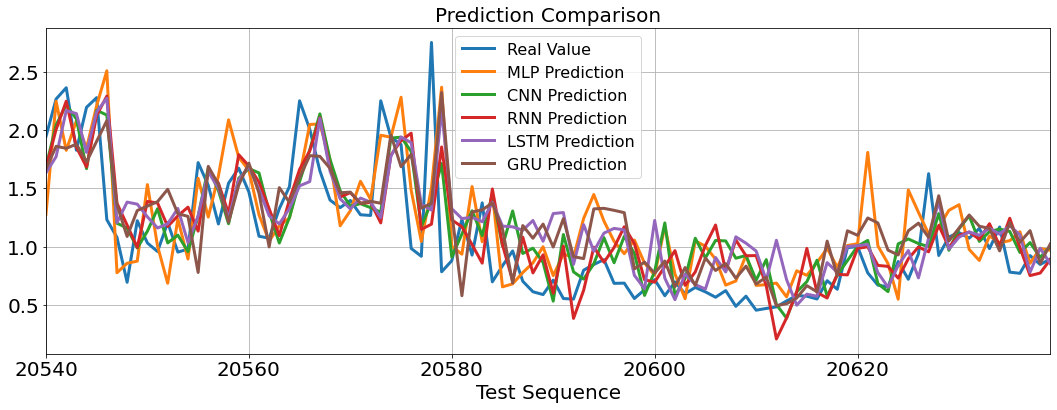

In [15]:
Y_pred_Final = pd.concat([Y_real, Y_pred_MLP, Y_pred_CNN, Y_pred_RNN, Y_pred_LSTM, Y_pred_GRU], axis=1)
Y_pred_Final.columns = ['Real Value']+[i+' Prediction' for i in ALGO_NAMES]
Y_pred_Final.plot(kind='line', figsize=(18,6), linewidth=3, fontsize=20,
                  xlim=(Y_pred_Final.index.min(),Y_pred_Final.index.max()))
plt.title('Prediction Comparison', fontsize=20)
plt.xlabel('Test Sequence', fontsize=20)
plt.ylabel('', fontsize=20)
plt.legend(fontsize=16)
plt.grid()
plt.show()

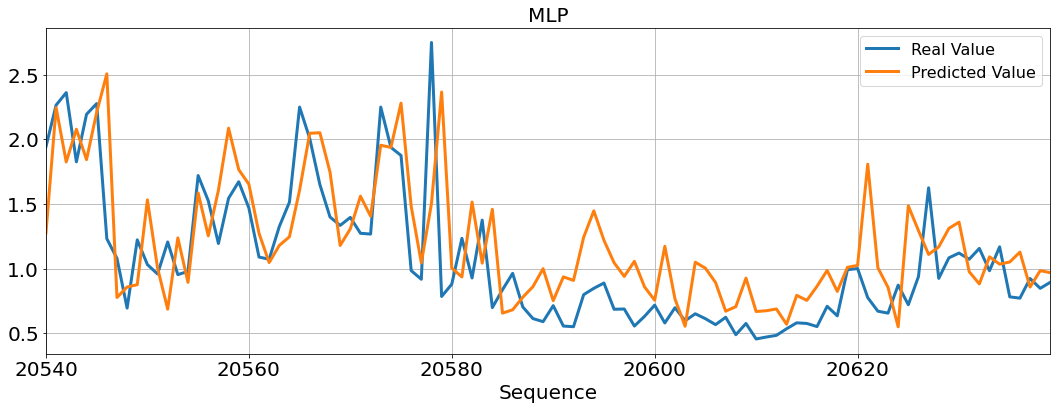

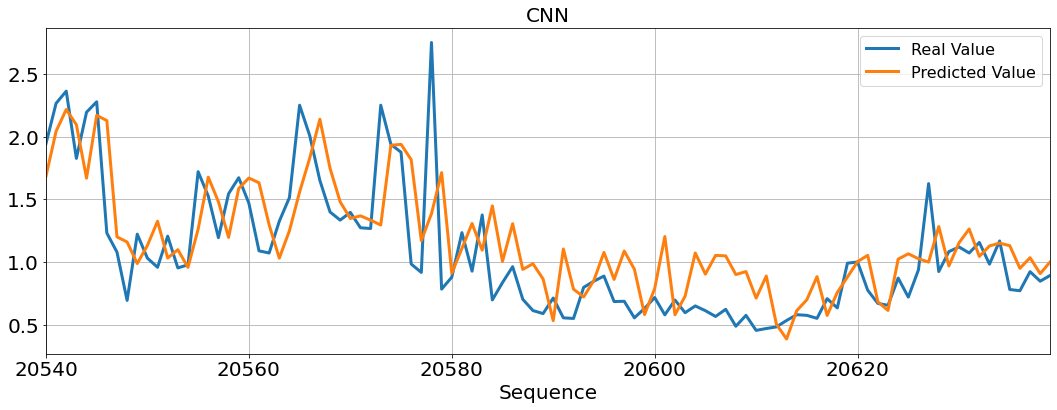

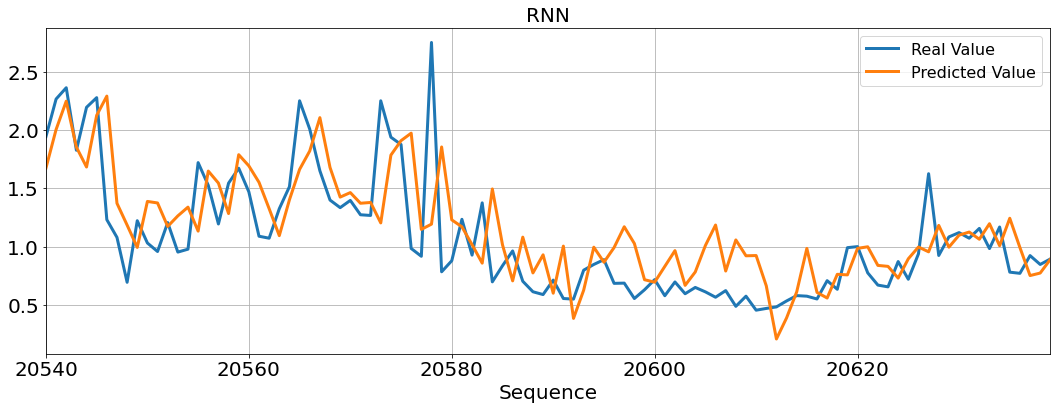

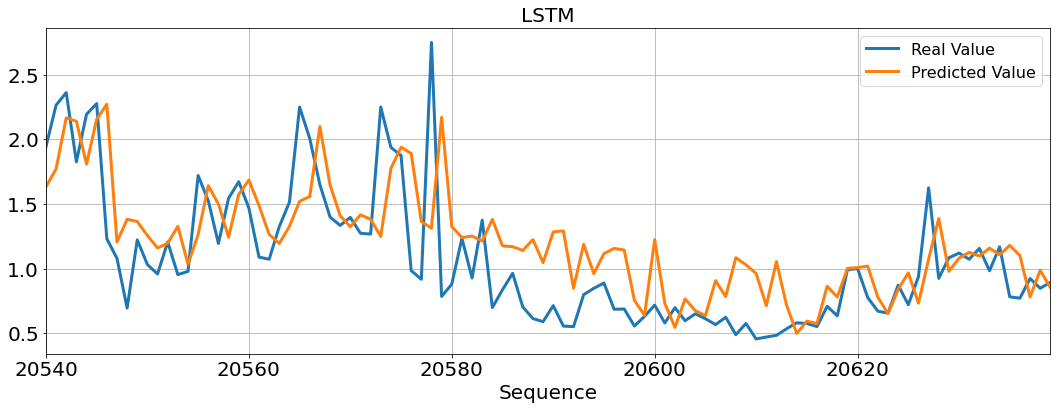

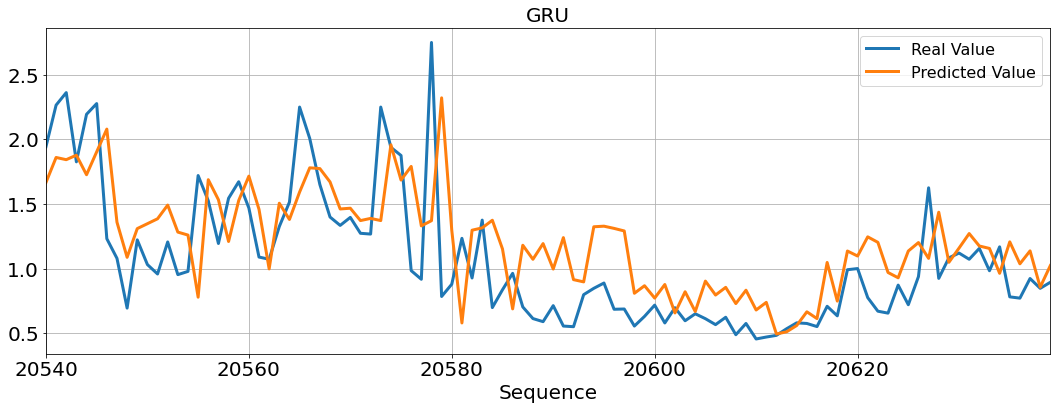

In [16]:
evaluation_reg_PredPlot(Y_real, Y_pred_MLP, title=ALGO_NAMES[0], ylabel='')
evaluation_reg_PredPlot(Y_real, Y_pred_CNN, title=ALGO_NAMES[1], ylabel='')
evaluation_reg_PredPlot(Y_real, Y_pred_RNN, title=ALGO_NAMES[2], ylabel='')
evaluation_reg_PredPlot(Y_real, Y_pred_LSTM, title=ALGO_NAMES[3], ylabel='')
evaluation_reg_PredPlot(Y_real, Y_pred_GRU, title=ALGO_NAMES[4], ylabel='')